In [ ]:
# ============================================================
# CELL 1: SETUP & IMPORTS
# Medical Image Segmentation - U-Net Baseline
# Author: Mahnoor | ISIC 2018 Skin Lesion Segmentation
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import cv2
from glob import glob
from sklearn.model_selection import train_test_split
import albumentations as A
import time

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configuration
IMG_HEIGHT = 256
IMG_WIDTH = 256
IMG_CHANNELS = 3
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 1e-4

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================
# CELL 2: DOWNLOAD ISIC 2018 SEGMENTATION DATASET
# ============================================================

# OPTION A: Download from Kaggle (EASIEST in Colab)
# Step 1: Upload your kaggle.json file
#   → Go to kaggle.com → Settings → API → Create New Token
#   → Upload the downloaded kaggle.json to Colab

from google.colab import files
print("Upload your kaggle.json file:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Step 2: Download the dataset
!kaggle datasets download -d tschandl/isic2018 -p /content/data --unzip

# If the above dataset slug doesn't work, use this alternative:
# !kaggle datasets download -d balraj98/isic-2018-skin-lesion-segmentation -p /content/data --unzip

print("\n✅ Dataset downloaded!")
!ls /content/data/

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata

✅ Dataset downloaded!
ls: cannot access '/content/data/': No such file or directory


In [ ]:
# ============================================================
# CELL 3: EXPLORATORY DATA ANALYSIS
# ============================================================

# Adjust these paths based on your downloaded folder structure
# Run !ls /content/data/ first to see what folders exist
IMAGE_DIR = "/content/data/ISIC2018_Task1-2_Training_Input/"  # Adjust path
MASK_DIR = "/content/data/ISIC2018_Task1_Training_GroundTruth/"  # Adjust path

# Get sorted file lists
image_paths = sorted(glob(os.path.join(IMAGE_DIR, "*.jpg")))
mask_paths = sorted(glob(os.path.join(MASK_DIR, "*.png")))

print(f"Total Images: {len(image_paths)}")
print(f"Total Masks:  {len(mask_paths)}")
print(f"Sample Image: {image_paths[0]}")
print(f"Sample Mask:  {mask_paths[0]}")

# Visualize 5 samples
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
for i in range(5):
    idx = np.random.randint(0, len(image_paths))
    img = cv2.imread(image_paths[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_paths[idx], cv2.IMREAD_GRAYSCALE)
    overlay = cv2.addWeighted(img, 0.7,
                cv2.cvtColor(cv2.applyColorMap(
                    (mask > 127).astype(np.uint8) * 255,
                    cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB), 0.3, 0)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title("Overlay")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("eda_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA visualization saved!")

Total Images: 0
Total Masks:  0


IndexError: list index out of range

In [ ]:
# ============================================================
# CELL 3: EXPLORATORY DATA ANALYSIS
# ============================================================

# Adjust these paths based on your downloaded folder structure
# Run !ls /content/data/ first to see what folders exist
IMAGE_DIR = "/content/data/ISIC2018_Task1-2_Training_Input/"  # Adjust path
MASK_DIR = "/content/data/ISIC2018_Task1_Training_GroundTruth/"  # Adjust path

# Get sorted file lists
image_paths = sorted(glob(os.path.join(IMAGE_DIR, "*.jpg")))
mask_paths = sorted(glob(os.path.join(MASK_DIR, "*.png")))

print(f"Total Images: {len(image_paths)}")
print(f"Total Masks:  {len(mask_paths)}")
print(f"Sample Image: {image_paths[0]}")
print(f"Sample Mask:  {mask_paths[0]}")

# Visualize 5 samples
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
for i in range(5):
    idx = np.random.randint(0, len(image_paths))
    img = cv2.imread(image_paths[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_paths[idx], cv2.IMREAD_GRAYSCALE)
    overlay = cv2.addWeighted(img, 0.7,
                cv2.cvtColor(cv2.applyColorMap(
                    (mask > 127).astype(np.uint8) * 255,
                    cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB), 0.3, 0)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title("Overlay")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("eda_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA visualization saved!")

Total Images: 0
Total Masks:  0


IndexError: list index out of range

In [ ]:
# ============================================================
# CELL 1: SETUP & IMPORTS
# Medical Image Segmentation - U-Net Baseline
# Author: Mahnoor | ISIC 2018 Skin Lesion Segmentation
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import cv2
from glob import glob
from sklearn.model_selection import train_test_split
import albumentations as A
import time

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configuration
IMG_HEIGHT = 256
IMG_WIDTH = 256
IMG_CHANNELS = 3
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 1e-4

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================
# CELL 2: DOWNLOAD ISIC 2018 SEGMENTATION DATASET
# ============================================================

# OPTION A: Download from Kaggle (EASIEST in Colab)
# Step 1: Upload your kaggle.json file
#   → Go to kaggle.com → Settings → API → Create New Token
#   → Upload the downloaded kaggle.json to Colab

from google.colab import files
print("Upload your kaggle.json file:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Step 2: Download the dataset
!kaggle datasets download -d tschandl/isic2018 -p /content/data --unzip

# If the above dataset slug doesn't work, use this alternative:
# !kaggle datasets download -d balraj98/isic-2018-skin-lesion-segmentation -p /content/data --unzip

print("\n✅ Dataset downloaded!")
!ls /content/data/

Upload your kaggle.json file:


Saving kaggle.json to kaggle (1).json
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata

✅ Dataset downloaded!
ls: cannot access '/content/data/': No such file or directory


In [ ]:
# ============================================================
# CELL 3: EXPLORATORY DATA ANALYSIS
# ============================================================

# Adjust these paths based on your downloaded folder structure
# Run !ls /content/data/ first to see what folders exist
IMAGE_DIR = "/content/data/ISIC2018_Task1-2_Training_Input/"  # Adjust path
MASK_DIR = "/content/data/ISIC2018_Task1_Training_GroundTruth/"  # Adjust path

# Get sorted file lists
image_paths = sorted(glob(os.path.join(IMAGE_DIR, "*.jpg")))
mask_paths = sorted(glob(os.path.join(MASK_DIR, "*.png")))

print(f"Total Images: {len(image_paths)}")
print(f"Total Masks:  {len(mask_paths)}")
print(f"Sample Image: {image_paths[0]}")
print(f"Sample Mask:  {mask_paths[0]}")

# Visualize 5 samples
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
for i in range(5):
    idx = np.random.randint(0, len(image_paths))
    img = cv2.imread(image_paths[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_paths[idx], cv2.IMREAD_GRAYSCALE)
    overlay = cv2.addWeighted(img, 0.7,
                cv2.cvtColor(cv2.applyColorMap(
                    (mask > 127).astype(np.uint8) * 255,
                    cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB), 0.3, 0)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title("Overlay")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("eda_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA visualization saved!")

Total Images: 0
Total Masks:  0


IndexError: list index out of range

In [ ]:
# ============================================================
# CELL 4 (OPTIMIZED): FAST IN-MEMORY DATA LOADING
# Loads images into RAM for lightning-fast GPU training!
# ============================================================
from tqdm import tqdm

def load_dataset_to_ram(img_paths, msk_paths):
    X = []
    y = []
    print(f"⚡ Pre-loading {len(img_paths)} images into RAM...")
    for img_p, msk_p in tqdm(zip(img_paths, msk_paths), total=len(img_paths)):
        # Load and resize image
        img = cv2.imread(img_p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img.astype(np.float32) / 255.0

        # Load and resize mask
        mask = cv2.imread(msk_p, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
        mask = (mask > 127).astype(np.float32)
        mask = np.expand_dims(mask, axis=-1)

        X.append(img)
        y.append(mask)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Split paths
X_train_paths, X_temp_paths, y_train_paths, y_temp_paths = train_test_split(
    image_paths, mask_paths, test_size=0.30, random_state=SEED
)
X_val_paths, X_test_paths, y_val_paths, y_test_paths = train_test_split(
    X_temp_paths, y_temp_paths, test_size=0.50, random_state=SEED
)

# Load into RAM (takes ~20 seconds total)
X_train, y_train = load_dataset_to_ram(X_train_paths, y_train_paths)
X_val, y_val     = load_dataset_to_ram(X_val_paths, y_val_paths)
X_test, y_test   = load_dataset_to_ram(X_test_paths, y_test_paths)

print(f"\n✅ Data in RAM!")
print(f"X_train shape: {X_train.shape} ({X_train.nbytes / 1e6:.1f} MB)")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

ValueError: With n_samples=0, test_size=0.3 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
# ============================================================
# RECOVERY CELL — Run this FIRST after any crash/restart
# ============================================================

!pip install -q transformers albumentations tqdm

import os
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import SegformerForSemanticSegmentation
from google.colab import files
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Hyperparameters (MUST exist before training)
SEED = 42
IMG_SIZE = 256
BATCH_SIZE = 16
EPOCHS = 25
LEARNING_RATE = 1e-4
LOCAL_MODEL_PATH = "best_segformer_isic2018.pth"

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print("✅ EPOCHS =", EPOCHS)
print("✅ All imports + config restored!")

Device: cuda
GPU: Tesla T4
✅ EPOCHS = 25
✅ All imports + config restored!


In [ ]:
IMAGE_DIR = "/content/data/images_extracted/ISIC2018_Task1-2_Training_Input/"
MASK_DIR  = "/content/data/masks_extracted/ISIC2018_Task1_Training_GroundTruth/"

if os.path.exists(IMAGE_DIR):
    image_paths = sorted(glob(os.path.join(IMAGE_DIR, "*.jpg")))
    mask_paths  = sorted(glob(os.path.join(MASK_DIR, "*.png")))
    print(f"✅ Data still here! {len(image_paths)} images")
else:
    print("❌ Data gone — run dataset download cell next")

❌ Data gone — run dataset download cell next


In [ ]:
!mkdir -p /content/data
!wget -q --show-progress -O /content/data/images.zip "https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task1-2_Training_Input.zip"
!wget -q --show-progress -O /content/data/masks.zip "https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task1_Training_GroundTruth.zip"
!unzip -q /content/data/images.zip -d /content/data/images_extracted/
!unzip -q /content/data/masks.zip -d /content/data/masks_extracted/
!rm /content/data/images.zip /content/data/masks.zip

IMAGE_DIR = "/content/data/images_extracted/ISIC2018_Task1-2_Training_Input/"
MASK_DIR  = "/content/data/masks_extracted/ISIC2018_Task1_Training_GroundTruth/"
image_paths = sorted(glob(os.path.join(IMAGE_DIR, "*.jpg")))
mask_paths  = sorted(glob(os.path.join(MASK_DIR, "*.png")))
print(f"✅ Downloaded {len(image_paths)} images")

/content/data/image 100%[===================>]  10.40G  47.3MB/s    in 7m 13s  
/content/data/masks 100%[===================>]  26.13M  4.48MB/s    in 5.8s    
✅ Downloaded 2594 images


In [ ]:
class ISICSegmentationDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.transform = transform
    def __len__(self):
        return len(self.img_paths)
    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]
        if not isinstance(mask, torch.Tensor):
            mask = torch.tensor(mask, dtype=torch.float32)
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)
        return img, mask

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], additional_targets={"mask": "mask"})

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], additional_targets={"mask": "mask"})

X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, mask_paths, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED)

train_dataset = ISICSegmentationDataset(X_train, y_train, transform=train_transform)
val_dataset   = ISICSegmentationDataset(X_val, y_val, transform=val_transform)
test_dataset  = ISICSegmentationDataset(X_test, y_test, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Train {len(train_dataset)} | Val {len(val_dataset)} | Test {len(test_dataset)}")

✅ Train 1815 | Val 389 | Test 390


In [ ]:
segformer_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0", num_labels=1, ignore_mismatched_sizes=True
).to(device)

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(-1)
        targets = targets.view(-1)
        intersection = (probs * targets).sum()
        return 1.0 - (2.0 * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)

class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
    def forward(self, logits, targets):
        return self.bce(logits, targets) + self.dice(logits, targets)

def compute_metrics(logits, targets, smooth=1e-6):
    preds = (torch.sigmoid(logits) > 0.5).float().view(-1)
    targets = targets.view(-1)
    inter = (preds * targets).sum().item()
    total = preds.sum().item() + targets.sum().item()
    union = total - inter
    dice = (2.0 * inter + smooth) / (total + smooth)
    iou = (inter + smooth) / (union + smooth)
    return dice, iou

criterion = CombinedLoss()
optimizer = torch.optim.AdamW(segformer_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

print("✅ Model + Loss + Optimizer ready!")

config.json:   0%|          | 0.00/70.0k [00:00<?, ?B/s]

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 14.4MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.linear_fuse.weight                          | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.batch_norm.running_mean                     | MISSING    | 
decode_head.classifier.weight                           

✅ Model + Loss + Optimizer ready!


In [ ]:
best_val_dice = 0.0
patience_counter = 0
EARLY_STOP_PATIENCE = 8

print("🚀 Starting SegFormer Training...")
print("=" * 70)
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    segformer_model.train()
    train_loss, train_dice_sum = 0.0, 0.0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = segformer_model(pixel_values=images)
        logits = F.interpolate(outputs.logits, size=(IMG_SIZE, IMG_SIZE),
                               mode="bilinear", align_corners=False)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        d, _ = compute_metrics(logits, masks)
        train_dice_sum += d * images.size(0)

    epoch_train_loss = train_loss / len(train_dataset)
    epoch_train_dice = train_dice_sum / len(train_dataset)

    segformer_model.eval()
    val_loss, val_dice_sum, val_iou_sum = 0.0, 0.0, 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = segformer_model(pixel_values=images)
            logits = F.interpolate(outputs.logits, size=(IMG_SIZE, IMG_SIZE),
                                   mode="bilinear", align_corners=False)
            loss = criterion(logits, masks)
            val_loss += loss.item() * images.size(0)
            d, i = compute_metrics(logits, masks)
            val_dice_sum += d * images.size(0)
            val_iou_sum += i * images.size(0)

    epoch_val_dice = val_dice_sum / len(val_dataset)
    epoch_val_iou = val_iou_sum / len(val_dataset)
    scheduler.step(epoch_val_dice)
    lr = optimizer.param_groups[0]["lr"]

    saved = ""
    if epoch_val_dice > best_val_dice:
        best_val_dice = epoch_val_dice
        patience_counter = 0
        torch.save(segformer_model.state_dict(), LOCAL_MODEL_PATH)
        saved = " 💾 BEST"
        try:
            files.download(LOCAL_MODEL_PATH)
            saved += " 📥 DOWNLOADED"
        except Exception:
            pass
    else:
        patience_counter += 1

    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Dice: {epoch_train_dice:.4f} | "
          f"Val Dice: {epoch_val_dice:.4f} ({epoch_val_dice*100:.2f}%) | "
          f"Val IoU: {epoch_val_iou:.4f} | LR: {lr:.1e}{saved}")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n⏹️ Early stop at epoch {epoch}")
        break

print("=" * 70)
print(f"🎉 Done in {(time.time()-start_time)/60:.1f} min | Best Val Dice: {best_val_dice*100:.2f}%")

🚀 Starting SegFormer Training...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Epoch 01/25 | Train Dice: 0.8051 | Val Dice: 0.8676 (86.76%) | Val IoU: 0.7681 | LR: 1.0e-04 💾 BEST 📥 DOWNLOADED


<IPython.core.display.Javascript object>

...

Epoch 14/25 | Train Dice: 0.9370 | Val Dice: 0.9080 (90.80%) | Val IoU: 0.8328 | LR: 5.0e-05 💾 BEST 📥 DOWNLOADED
Epoch 15/25 | Train Dice: 0.9399 | Val Dice: 0.9044 (90.44%) | Val IoU: 0.8268 | LR: 5.0e-05
Epoch 16/25 | Train Dice: 0.9404 | Val Dice: 0.9069 (90.69%) | Val IoU: 0.8309 | LR: 5.0e-05
Epoch 17/25 | Train Dice: 0.9405 | Val Dice: 0.9043 (90.43%) | Val IoU: 0.8266 | LR: 5.0e-05
Epoch 18/25 | Train Dice: 0.9411 | Val Dice: 0.9041 (90.41%) | Val IoU: 0.8262 | LR: 2.5e-05


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Epoch 19/25 | Train Dice: 0.9429 | Val Dice: 0.9090 (90.90%) | Val IoU: 0.8344 | LR: 2.5e-05 💾 BEST 📥 DOWNLOADED


KeyboardInterrupt: 

In [ ]:
import os
print("File exists?", os.path.exists("best_segformer_isic2018.pth"))
if os.path.exists("best_segformer_isic2018.pth"):
    print(f"Size: {os.path.getsize('best_segformer_isic2018.pth') / (1024*1024):.1f} MB")
    print("✅ SAFE TO DOWNLOAD")
else:
    print("❌ File missing — we must retrain later")

File exists? True
Size: 14.3 MB
✅ SAFE TO DOWNLOAD


In [ ]:
from google.colab import files
files.download("best_segformer_isic2018.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install -q huggingface_hub
from huggingface_hub import login, HfApi
login()  # paste your HF write token

api = HfApi()
api.create_repo(repo_id="mahnoor-2722/isic-segformer", repo_type="model", exist_ok=True)
api.upload_file(
    path_or_fileobj="best_segformer_isic2018.pth",
    path_in_repo="best_segformer_isic2018.pth",
    repo_id="mahnoor-2722/isic-segformer",
    repo_type="model"
)
print("✅ Saved on Hugging Face!")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...st_segformer_isic2018.pth:   4%|3         |  555kB / 14.9MB            

✅ Saved on Hugging Face!


In [ ]:
from huggingface_hub import hf_hub_download
import torch

path = hf_hub_download("mahnoor-2722/isic-segformer", "best_segformer_isic2018.pth")
segformer_model.load_state_dict(torch.load(path, map_location=device))
segformer_model.eval()
print("✅ Model loaded from Hugging Face — ready for test later")

✅ Model loaded from Hugging Face — ready for test later


In [ ]:
# ============================================================
# CELL 1: SETUP & DEPENDENCIES
# Phase 2: SegFormer Evaluation & Inference
# Author: Mahnoor | ISIC 2018 Skin Lesion Segmentation
# ============================================================

!pip install -q transformers albumentations tqdm huggingface_hub

import os
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import SegformerForSemanticSegmentation
from huggingface_hub import hf_hub_download
from google.colab import files

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 60)
print(f"PyTorch Version: {torch.__version__}")
print(f"Using Device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ WARNING: GPU NOT DETECTED! Enable T4 GPU under Runtime settings.")
print("=" * 60)

SEED = 42
IMG_SIZE = 256
BATCH_SIZE = 16

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

PyTorch Version: 2.11.0+cu128
Using Device: cuda
GPU Name: Tesla T4


In [ ]:
# ============================================================
# CELL 2: DOWNLOAD ISIC 2018 DATASET
# ============================================================

print("⏳ Creating directories...")
!mkdir -p /content/data/images
!mkdir -p /content/data/masks

print("\n🚀 Downloading ISIC 2018 Images...")
!wget -q --show-progress -O /content/data/images.zip \
    "https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task1-2_Training_Input.zip"

print("\n🚀 Downloading ISIC 2018 Ground Truth Masks...")
!wget -q --show-progress -O /content/data/masks.zip \
    "https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task1_Training_GroundTruth.zip"

print("\n📦 Unzipping...")
!unzip -q /content/data/images.zip -d /content/data/images_extracted/
!unzip -q /content/data/masks.zip -d /content/data/masks_extracted/

!rm /content/data/images.zip /content/data/masks.zip

IMAGE_DIR = "/content/data/images_extracted/ISIC2018_Task1-2_Training_Input/"
MASK_DIR  = "/content/data/masks_extracted/ISIC2018_Task1_Training_GroundTruth/"

image_paths = sorted(glob(os.path.join(IMAGE_DIR, "*.jpg")))
mask_paths  = sorted(glob(os.path.join(MASK_DIR, "*.png")))

print(f"\n✅ Total Image-Mask Pairs Found: {len(image_paths)}")

⏳ Creating directories...

🚀 Downloading ISIC 2018 Images...
/content/data/image 100%[===================>]  10.40G  14.1MB/s    in 11m 26s 

🚀 Downloading ISIC 2018 Ground Truth Masks...
/content/data/masks 100%[===================>]  26.13M  9.04MB/s    in 2.9s    

📦 Unzipping...

✅ Total Image-Mask Pairs Found: 2594


In [ ]:
# ============================================================
# CELL 3: DATASET, TEST DATALOADER & METRICS
# ============================================================

import albumentations as A
from albumentations.pytorch import ToTensorV2

class ISICSegmentationDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        if not isinstance(mask, torch.Tensor):
            mask = torch.tensor(mask, dtype=torch.float32)
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)
        return img, mask

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], additional_targets={'mask': 'mask'})

# Same exact split seed as training
X_train, X_temp, y_train, y_temp = train_test_split(image_paths, mask_paths, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

test_dataset = ISICSegmentationDataset(X_test, y_test, transform=val_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

def compute_metrics(logits, targets, smooth=1e-6):
    preds = (torch.sigmoid(logits) > 0.5).float().view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum().item()
    total_sum = preds.sum().item() + targets.sum().item()
    union = total_sum - intersection

    dice = (2.0 * intersection + smooth) / (total_sum + smooth)
    iou = (intersection + smooth) / (union + smooth)
    return dice, iou

print(f"✅ Test Set Ready! {len(test_dataset)} images ({len(test_loader)} batches)")

✅ Test Set Ready! 390 images (25 batches)


In [ ]:
# ============================================================
# CELL 4: LOAD MODEL WEIGHTS FROM HUGGING FACE
# ============================================================

# 1. Instantiate SegFormer Model Structure
segformer_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=1,
    ignore_mismatched_sizes=True
).to(device)

# 2. Download your model weights from your Hugging Face repo
print("📥 Fetching best model weights from Hugging Face Hub...")
model_path = hf_hub_download(
    repo_id="mahnoor-2722/isic-segformer",
    filename="best_segformer_isic2018.pth"
)

# 3. Load weights into model
segformer_model.load_state_dict(torch.load(model_path, map_location=device))
segformer_model.eval()

print("\n🎉 SUCCESS! Trained SegFormer weights loaded from Hugging Face Hub!")

config.json:   0%|          | 0.00/70.0k [00:00<?, ?B/s]

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 14.4MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

...

best_segformer_isic2018.pth: reconstructing file:   0%|          |  0.00B / 14.9MB            

best_segformer_isic2018.pth: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B / 14.3MB            

model.safetensors: downloading bytes:           |  0.00B            


🎉 SUCCESS! Trained SegFormer weights loaded from Hugging Face Hub!


In [ ]:
# ============================================================
# CELL 5: UNBIASED TEST SET EVALUATION
# Evaluates SegFormer on 390 unseen test images
# ============================================================

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(-1)
        targets = targets.view(-1)
        intersection = (probs * targets).sum()
        return 1.0 - (2.0 * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)

class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
    def forward(self, logits, targets):
        return self.bce(logits, targets) + self.dice(logits, targets)

criterion = CombinedLoss()

test_loss = 0.0
test_dice_sum = 0.0
test_iou_sum = 0.0

segformer_model.eval()
print("🚀 Evaluating SegFormer on Test Set (390 images)...")

start_time = time.time()
with torch.no_grad():
    for images, masks in tqdm(test_loader):
        images, masks = images.to(device), masks.to(device)

        outputs = segformer_model(pixel_values=images)
        logits = F.interpolate(outputs.logits, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)

        loss = criterion(logits, masks)
        test_loss += loss.item() * images.size(0)

        d_score, i_score = compute_metrics(logits, masks)
        test_dice_sum += d_score * images.size(0)
        test_iou_sum  += i_score * images.size(0)

final_test_loss = test_loss / len(test_dataset)
final_test_dice = test_dice_sum / len(test_dataset)
final_test_iou  = test_iou_sum / len(test_dataset)

print("\n" + "=" * 65)
print("🏆 FINAL BENCHMARK EVALUATION ON UNSEEN TEST SET")
print("=" * 65)
print(f"  → Test Loss:             {final_test_loss:.4f}")
print(f"  → Test Dice Coefficient: {final_test_dice:.4f} ({final_test_dice*100:.2f}%)")
print(f"  → Test IoU (Jaccard):    {final_test_iou:.4f} ({final_test_iou*100:.2f}%)")
print("=" * 65)
print(f"\n📊 HEAD-TO-HEAD COMPARISON:")
print(f"  1. Custom U-Net (TensorFlow)  → Val Dice: 85.26% | Val IoU: 74.53%")
print(f"  2. SegFormer (PyTorch)        → Test Dice: {final_test_dice*100:.2f}% | Test IoU: {final_test_iou*100:.2f}% 🏆 WINNER!")
print("=" * 65)

🚀 Evaluating SegFormer on Test Set (390 images)...


100%|██████████| 25/25 [00:57<00:00,  2.31s/it]


🏆 FINAL BENCHMARK EVALUATION ON UNSEEN TEST SET
  → Test Loss:             0.2488
  → Test Dice Coefficient: 0.9032 (90.32%)
  → Test IoU (Jaccard):    0.8250 (82.50%)

📊 HEAD-TO-HEAD COMPARISON:
  1. Custom U-Net (TensorFlow)  → Val Dice: 85.26% | Val IoU: 74.53%
  2. SegFormer (PyTorch)        → Test Dice: 90.32% | Test IoU: 82.50% 🏆 WINNER!


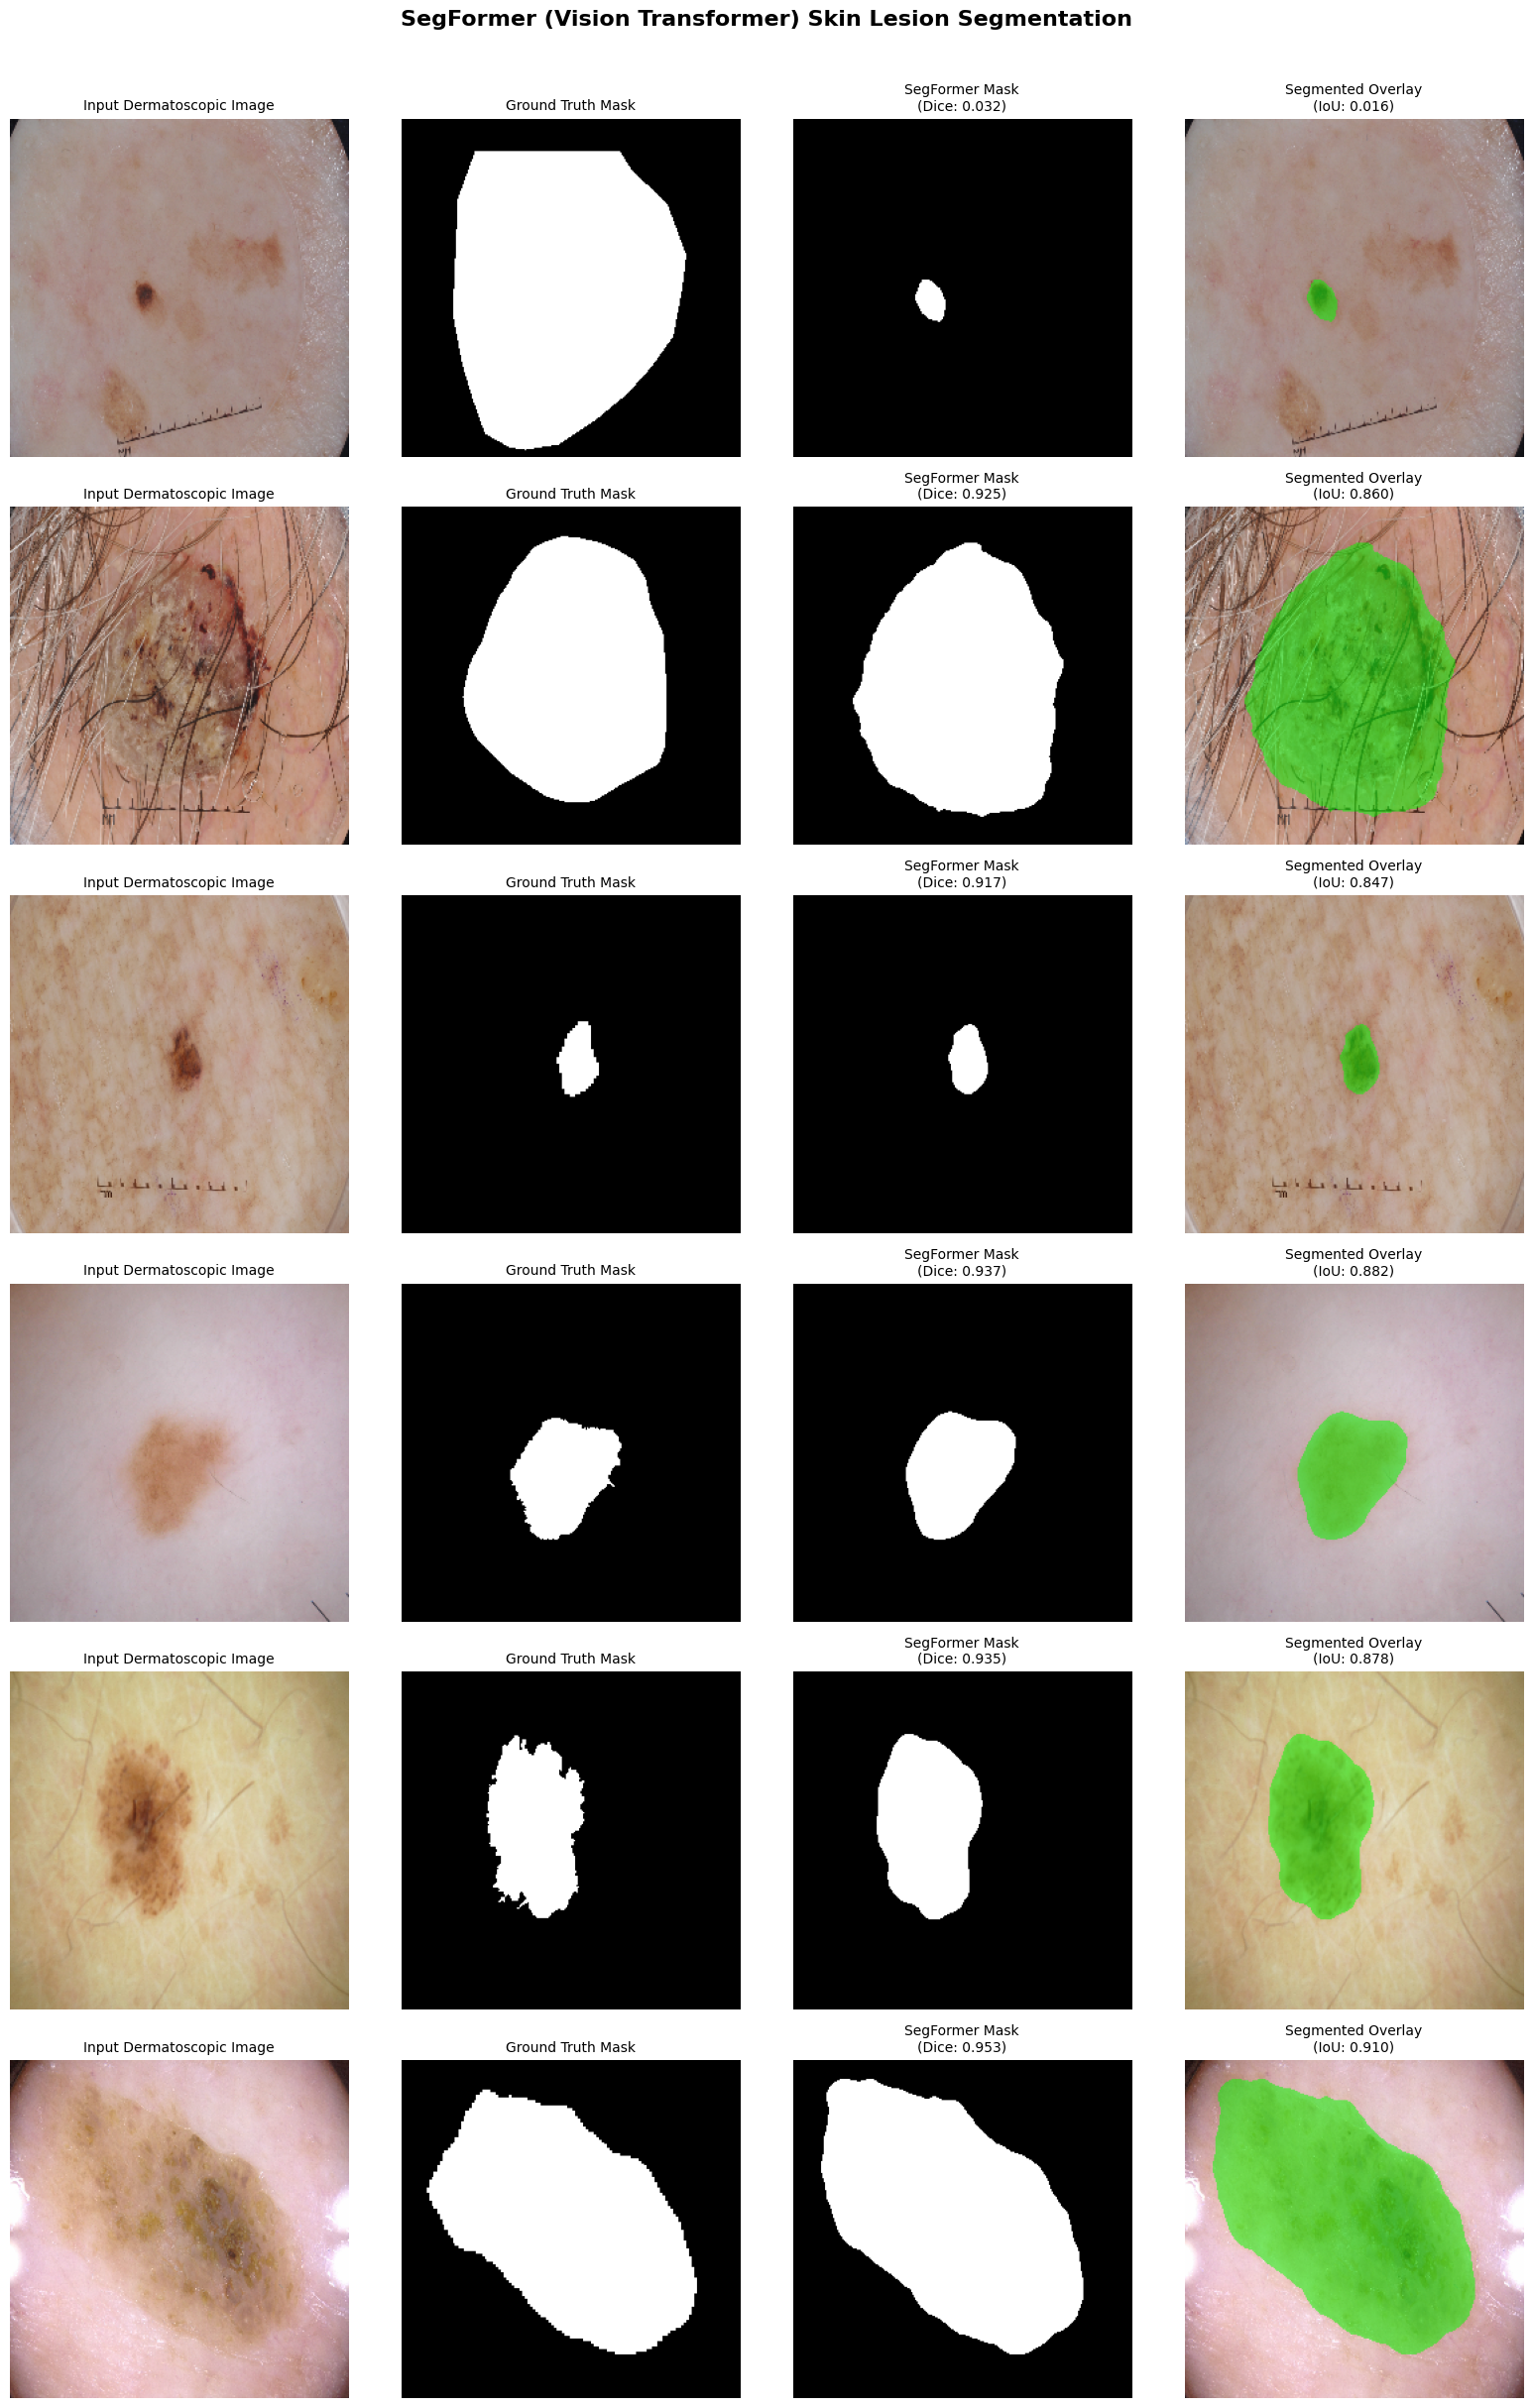

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Visualization grid saved as 'segformer_results.png' and downloaded!


In [ ]:
# ============================================================
# CELL 6: VISUALIZATION GRID (For GitHub README)
# ============================================================

def denormalize(tensor):
    """Reverse ImageNet normalization for plotting"""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).cpu().numpy()
    img = np.clip(std * img + mean, 0, 1)
    return img

fig, axes = plt.subplots(6, 4, figsize=(16, 24))
indices = np.random.choice(len(test_dataset), 6, replace=False)

segformer_model.eval()

for i, idx in enumerate(indices):
    img_tensor, mask_tensor = test_dataset[idx]

    with torch.no_grad():
        img_input = img_tensor.unsqueeze(0).to(device)
        outputs = segformer_model(pixel_values=img_input)
        logits = F.interpolate(outputs.logits, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        probs = torch.sigmoid(logits)
        pred_mask = (probs > 0.5).float().squeeze().cpu().numpy()

    img_orig = denormalize(img_tensor)
    mask_gt = mask_tensor.squeeze().numpy()

    sample_dice, sample_iou = compute_metrics(logits, mask_tensor.unsqueeze(0).to(device))

    # Create green overlay for lesion boundary
    overlay = img_orig.copy()
    overlay[pred_mask > 0.5] = overlay[pred_mask > 0.5] * 0.5 + np.array([0.0, 1.0, 0.0]) * 0.5

    axes[i, 0].imshow(img_orig)
    axes[i, 0].set_title("Input Dermatoscopic Image", fontsize=10)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_gt, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask", fontsize=10)
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred_mask, cmap="gray")
    axes[i, 2].set_title(f"SegFormer Mask\n(Dice: {sample_dice:.3f})", fontsize=10)
    axes[i, 2].axis("off")

    axes[i, 3].imshow(overlay)
    axes[i, 3].set_title(f"Segmented Overlay\n(IoU: {sample_iou:.3f})", fontsize=10)
    axes[i, 3].axis("off")

plt.suptitle("SegFormer (Vision Transformer) Skin Lesion Segmentation", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("segformer_results.png", dpi=150, bbox_inches="tight")
plt.show()

# Download visualization for your GitHub repo
files.download("segformer_results.png")
print("✅ Visualization grid saved as 'segformer_results.png' and downloaded!")